<div style="background:linear-gradient(135deg,#4c0519 0%,#be123c 55%,#fb7185 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 141 &#183; Take It Further</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Multi-File, Multi-Date EDA: Take It Further</div>
  <div style="font-size:15px;color:#ffe4e6;max-width:760px;line-height:1.6">Five deeper cuts at data cleaning: the day-first date trap, why key-cleaning must come before dedup, validating a merge with a data contract, wrapping it all in a reusable pipeline, and how the missing amounts move the headline revenue.</div>
  <div style="margin-top:16px;font-size:13px;color:#fecdd3">Statistics, Data Science and AI: A Visual Handbook &#183; John Fisher &#183; 2026</div>
</div>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
EM='#e11d48'; DEEP='#be123c'; LIGHT='#fecdd3'; INK='#1a2138'; GRID='#e6e9f2'; GREEN='#059669'; AMBER='#d97706'; GREY='#94a3b8'
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','figure.dpi':110,'font.size':11,
   'axes.edgecolor':GRID,'axes.grid':True,'grid.color':GRID,'axes.axisbelow':True,'axes.spines.top':False,
   'axes.spines.right':False,'axes.titlesize':12,'axes.titleweight':'bold','legend.frameon':False})
BASE='https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/'
NA=['', 'N/A', 'null', '-']
def loadna(name):
    try:    return pd.read_csv('../../data/'+name, na_values=NA, keep_default_na=True)
    except FileNotFoundError: return pd.read_csv(BASE+name, na_values=NA, keep_default_na=True)
orders_raw = loadna('case-study-multi-file-and-datetime-eda--orders.csv'); customers_raw = loadna('case-study-multi-file-and-datetime-eda--customers.csv'); returns_raw = loadna('case-study-multi-file-and-datetime-eda--returns.csv')
print('raw:', len(orders_raw), 'orders |', len(customers_raw), 'customers |', len(returns_raw), 'returns')

raw: 1240 orders | 315 customers | 150 returns


<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">EXTENSION 1</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The day-first date trap</div>
<div style="color:#4a5578;margin-top:6px">The same text, parsed two ways, gives two different histories.</div>
</div>

The single most dangerous cleaning bug is a silently mis-parsed date. Order dates like `03/04/2024` are ambiguous: is it March 4th (US) or April 3rd (most of the world)? We parse the raw column both ways and see the damage. Where the day exceeds 12, pandas can tell which field is which, but for genuinely ambiguous values it silently **swaps** day and month under the wrong rule, with no error at all, distorting the monthly trend.

dates that became invalid (NaT) under day-first: 0
dates that silently SWAPPED to a different valid day: 303


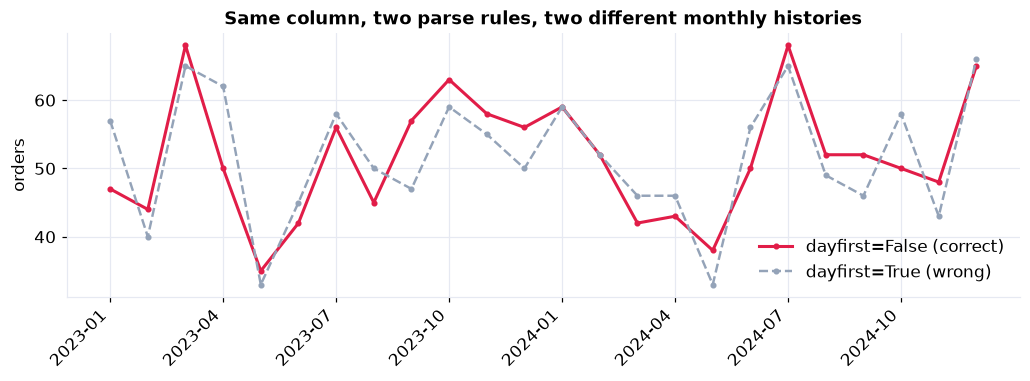

In [2]:
good = pd.to_datetime(orders_raw.order_date, format='mixed', dayfirst=False, errors='coerce')  # correct (US)
bad  = pd.to_datetime(orders_raw.order_date, format='mixed', dayfirst=True,  errors='coerce')  # wrong assumption
changed = (good != bad) & good.notna() & bad.notna()
print(f'dates that became invalid (NaT) under day-first: {int(bad.isna().sum()) - int(good.isna().sum())}')
print(f'dates that silently SWAPPED to a different valid day: {int(changed.sum())}')
fig, ax = plt.subplots(figsize=(9.5,3.6))
gm = good.dt.to_period('M').value_counts().sort_index(); bm = bad.dt.to_period('M').value_counts().sort_index()
ax.plot(gm.index.astype(str), gm.values, color=EM, lw=2, marker='o', ms=3, label='dayfirst=False (correct)')
ax.plot(bm.index.astype(str), bm.values, color=GREY, lw=1.6, ls='--', marker='o', ms=3, label='dayfirst=True (wrong)')
ax.set_title('Same column, two parse rules, two different monthly histories'); ax.legend()
ax.set_xticks(ax.get_xticks()[::3]); plt.xticks(rotation=45, ha='right'); ax.set_ylabel('orders'); plt.tight_layout(); plt.show()

Here nothing fails outright, pandas is smart enough to keep `03/15` as March, but **303 dates silently swap** into the wrong month, and the two monthly curves diverge even though the raw text never changed. That silent success is exactly what makes it dangerous: a date bug produces no error message, only wrong answers. The defense is to **never let pandas guess**, know your source's convention, set `dayfirst` explicitly, pass `errors='coerce'`, and then sanity-check the parsed date range and the monthly counts.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">EXTENSION 2</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Clean the key, or the join silently drops matches</div>
<div style="color:#4a5578;margin-top:6px">A mismatched key does not error, it just fails to match.</div>
</div>

The files link on `customer_id`. If the ids are not normalized on **both** sides, a lowercase or space-padded id simply fails to match its partner, and pandas quietly turns the order into an orphan, no warning, no error. We measure the damage by joining with the **raw** keys versus the **cleaned** keys.

In [3]:
orphans = lambda o, c: int((o.merge(c, on='customer_id', how='left', indicator=True)['_merge']=='left_only').sum())
O = orders_raw.drop_duplicates(); C = customers_raw.drop_duplicates()
raw_orphan = orphans(O, C)                                    # join on the messy keys as-is
Oc = O.copy(); Cc = C.copy()
Oc['customer_id'] = Oc['customer_id'].str.strip().str.upper()
Cc['customer_id'] = Cc['customer_id'].str.strip().str.upper(); Cc = Cc.drop_duplicates()
clean_orphan = orphans(Oc, Cc)
print(f'join on RAW keys    : {raw_orphan} orphan orders  ({(1-raw_orphan/len(O))*100:.1f}% matched)')
print(f'join on CLEANED keys: {clean_orphan} orphan orders  ({(1-clean_orphan/len(Oc))*100:.1f}% matched)')
print(f'a dirty key silently lost {raw_orphan-clean_orphan} real matches.')

join on RAW keys    : 332 orphan orders  (72.3% matched)
join on CLEANED keys: 8 orphan orders  (99.3% matched)
a dirty key silently lost 324 real matches.


With the raw keys, **332 of 1,200 orders (about 28%) fail to find their customer** and become orphans, not because the customer is missing, but because `"c0007"` and `"C0007"` are different strings. Cleaning the key on both sides first collapses that to the **8 genuinely orphaned** orders. A dirty join key does not raise an error; it silently deletes matches, quietly biasing every per-customer and per-region number. That is why normalizing the key on **every** table before joining is non-negotiable, and why you always check the match rate afterward.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">EXTENSION 3</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Validate the merge with a data contract</div>
<div style="color:#4a5578;margin-top:6px">Make the join assert what you believe.</div>
</div>

A silent many-to-many join is a classic way to explode a row count and inflate every total. pandas' `merge` can **enforce** the relationship you expect with `validate=`, turning a wrong assumption into a loud error instead of a quiet bug. We also quantify the orphans and decide what to do with them.

In [4]:
cust = customers_raw.copy(); cust['customer_id'] = cust['customer_id'].str.strip().str.upper(); cust = cust.drop_duplicates()
ords = orders_raw.copy(); ords['customer_id'] = ords['customer_id'].str.strip().str.upper(); ords = ords.drop_duplicates()
try:
    m = ords.merge(cust, on='customer_id', how='left', validate='m:1')   # many orders to one customer
    print('validate="m:1" passed: each customer_id is unique in the customer table.')
except pd.errors.MergeError as e:
    print('MergeError:', e)
orphan = m[m.region.isna() & ~m.customer_id.isin(cust.customer_id)]
print(f'orphan orders: {ords.customer_id.isin(cust.customer_id).eq(False).sum()}  (customer_id not in the customer table)')
print('policy: keep them, flagged, so revenue still counts, but exclude from any per-region breakdown.')

validate="m:1" passed: each customer_id is unique in the customer table.
orphan orders: 8  (customer_id not in the customer table)
policy: keep them, flagged, so revenue still counts, but exclude from any per-region breakdown.


Because we deduplicated the customer key first, `validate='m:1'` passes, a machine-checked guarantee that the join cannot fan out. Had a duplicate customer slipped through, this line would have raised a `MergeError` at the source of the bug rather than letting a doubled revenue total sail downstream. The eight orphans are then a **policy** decision: we keep them so their revenue still counts, flag them, and simply omit them from per-region cuts.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">EXTENSION 4</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Wrap it in a reusable, asserting pipeline</div>
<div style="color:#4a5578;margin-top:6px">Cleaning you did once should run again tomorrow.</div>
</div>

Ad-hoc cleaning in scattered cells is not reproducible. We fold every step into one `clean()` function that takes the raw files and returns the analysis table, with **assertions** baked in, a lightweight *data contract* that fails loudly if next month's export breaks an assumption.

In [5]:
def clean(orders, customers, returns):
    o, c, r = orders.copy(), customers.copy(), returns.copy()
    for d in (o, c): d['customer_id'] = d['customer_id'].str.strip().str.upper()
    o = o.drop_duplicates().copy(); c = c.drop_duplicates().copy()
    o['order_date'] = pd.to_datetime(o['order_date'], format='mixed', dayfirst=False, errors='coerce')
    r['return_date'] = pd.to_datetime(r['return_date'], format='%Y/%m/%d', errors='coerce')
    o['amount'] = pd.to_numeric(o['amount'].str.replace(r'[$,]','',regex=True), errors='coerce')
    o['status'] = o['status'].str.strip().str.lower().replace({'canceled':'cancelled'})
    rmap = {'USA':'United States','U.S.':'United States','US':'United States','CA':'Canada','UK':'United Kingdom','U.K.':'United Kingdom'}
    c['region'] = c['region'].str.strip().replace(rmap).str.title().replace({'Uk':'United Kingdom','Ca':'Canada','Us':'United States'})
    m = o.merge(c, on='customer_id', how='left', validate='m:1')
    m = m.merge(r[['order_id','return_date']], on='order_id', how='left')
    m['is_returned'] = m['return_date'].notna()
    # --- data contract ---
    assert m['order_id'].is_unique, 'duplicate order ids'
    assert m['order_date'].dt.year.between(2023, 2024).all(), 'dates out of range'
    assert (m['amount'].dropna() >= 0).all(), 'negative amounts'
    assert set(m['status'].unique()) <= {'delivered','shipped','cancelled'}, 'unexpected status'
    return m
tbl = clean(orders_raw, customers_raw, returns_raw)
print('clean() produced', tbl.shape, 'and passed every assertion.')
print(f"realized revenue: ${tbl.loc[tbl.status!='cancelled','amount'].sum():,.0f}")

clean() produced (1200, 9) and passed every assertion.
realized revenue: $388,045


One call now reproduces the entire chapter, and if a future export sneaks in a negative amount or a fourth status, an assertion stops the pipeline **before** a wrong number reaches a dashboard. This is the difference between a one-off notebook and a maintainable process: the same discipline as unit tests, applied to data.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">EXTENSION 5</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How much do the missing amounts move revenue?</div>
<div style="color:#4a5578;margin-top:6px">Be honest about what missing data does to the headline.</div>
</div>

Some orders arrived with no amount at all, so our realized-revenue figure is an **under-count**. How much does that matter? We bracket the headline three ways, exclude the missing (the chapter's figure), impute the overall mean, and impute each order's **regional** mean, to show the plausible range.

exclude missing (lower bound) : $388,045   <- the chapter figure
impute overall mean           : $399,090
impute regional mean          : $399,058
the 30 missing amounts move the headline by up to $11,013 (~2.8%).


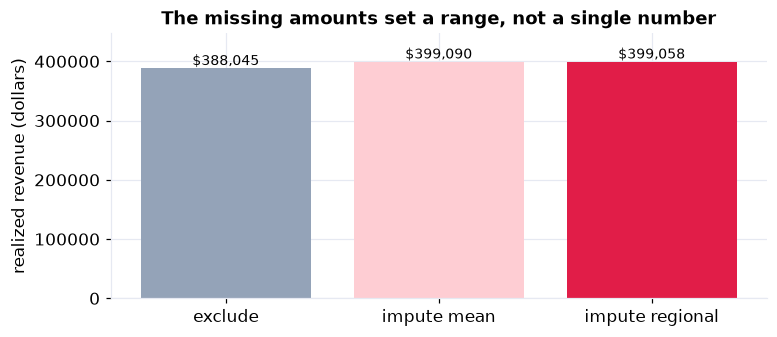

In [6]:
m = clean(orders_raw, customers_raw, returns_raw)
real = m[m.status!='cancelled'].copy()
excl = real.amount.sum()
imp_mean = real.amount.fillna(real.amount.mean()).sum()
imp_reg  = real.amount.fillna(real.groupby('region')['amount'].transform('mean')).fillna(real.amount.mean()).sum()
print(f'exclude missing (lower bound) : ${excl:,.0f}   <- the chapter figure')
print(f'impute overall mean           : ${imp_mean:,.0f}')
print(f'impute regional mean          : ${imp_reg:,.0f}')
print(f'the {int(real.amount.isna().sum())} missing amounts move the headline by up to ${imp_reg-excl:,.0f} (~{(imp_reg/excl-1)*100:.1f}%).')
fig, ax = plt.subplots(figsize=(7.2,3.2))
labels=['exclude','impute mean','impute regional']; vals=[excl, imp_mean, imp_reg]
ax.bar(labels, vals, color=[GREY, LIGHT, EM]); ax.set_ylabel('realized revenue (dollars)')
ax.set_title('The missing amounts set a range, not a single number')
for i,v in enumerate(vals): ax.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, max(vals)*1.12); plt.tight_layout(); plt.show()

Excluding the missing gives a firm lower bound; imputing the mean or the regional mean nudges the total up by a small, bounded amount. The honest way to report the headline is as that **range**, not a single false-precision figure, and to flag the missing amounts for the source system to fix. Quantifying the uncertainty a data gap creates is itself a deliverable.

---
**The one idea to keep: cleaning is where analyses are won or lost, so treat it as engineering, normalize keys before you join or dedup, parse every date and number explicitly with failures coerced and counted, validate the merge with a contract, wrap it in a reusable asserting function, and report the range that missing data implies rather than a single false-precise number.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook &#183; &#169; 2026 John Fisher</div>